# lncRNA Case Studies (hg38 → mm39)

Detailed per-gene visualisation of well-known lncRNAs:
reference islands, query islands, matched pairs with MMD scores.

Genes: MALAT1, NEAT1, XIST, HOTAIR, H19, MEG3, GAS5, BISPR, KCNQ1OT1

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

PIPELINE_DIR = REPO_ROOT / "hg38_vs_mm39_primary_only"
BED_DIR = PIPELINE_DIR / "intermediate_bed_files"

plt.rcParams["figure.dpi"] = 120

In [2]:
# Target genes — ENSG ID (without version) → display name
TARGETS = {
    "ENSG00000251562": "MALAT1",
    "ENSG00000245532": "NEAT1",
    "ENSG00000229807": "XIST",
    "ENSG00000228630": "HOTAIR",
    "ENSG00000130600": "H19",
    "ENSG00000214548": "MEG3",
    "ENSG00000234741": "GAS5",
    "ENSG00000282851": "BISPR",
    "ENSG00000269821": "KCNQ1OT1",
}

## Load data

In [ ]:
def parse_bed12(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) < 12:
                continue
            bsizes = [int(x) for x in p[10].rstrip(",").split(",") if x]
            bstarts = [int(x) for x in p[11].rstrip(",").split(",") if x]
            start = int(p[1])
            blocks = [(start + bs, start + bs + bz) for bs, bz in zip(bstarts, bsizes)]
            rows.append({
                "chrom": p[0], "start": int(p[1]), "end": int(p[2]),
                "name": p[3], "strand": p[5], "blocks": blocks,
            })
    return rows


# Union transcripts (gene spans)
union_entries = parse_bed12(PIPELINE_DIR / "union_transcripts.bed")
union_map = {e["name"]: e for e in union_entries}

# Reference islands
ref_islands_all = parse_bed12(BED_DIR / "raw_reference_islands.bed")

# Query islands
query_islands_all = parse_bed12(BED_DIR / "raw_query_islands.bed")

# Aligned BEDs
aligned_query_all = parse_bed12(BED_DIR / "aligned_islands_query.bed")
aligned_ref_all = parse_bed12(BED_DIR / "aligned_islands_reference.bed")

# Island alignment results
aln = pd.read_csv(PIPELINE_DIR / "island_alignment_results.tsv", sep="\t")

# TOGA regions
toga = pd.read_csv(PIPELINE_DIR / "toga_mini_results" / "rna_orthologous_regions.tsv", sep="\t")

# Metadata
meta = pd.read_csv(PIPELINE_DIR / "union_transcripts_metadata.tsv", sep="\t")

# Union-to-isoforms mapping (tracks merged genes)
with open(PIPELINE_DIR / "mappings" / "union_to_isoforms.json") as f:
    union_to_isoforms = json.load(f)

# Build reverse index: ENSG base ID → union transcript ID (handles merges)
_ensg_to_uid = {}
for uid, info in union_to_isoforms.items():
    for gid in info.get("merged_gene_ids", []):
        base = gid.rsplit(".", 1)[0]
        _ensg_to_uid[base] = uid
    # Also index the gene ID embedded in the union ID itself
    if uid.startswith("U_"):
        base = uid[2:].rsplit(".", 1)[0]
        _ensg_to_uid[base] = uid

print("Data loaded.")

Data loaded.


In [4]:
def find_union_id(ensg_base):
    """Find the union transcript ID for an ENSG base, including merged genes."""
    if ensg_base in _ensg_to_uid:
        return _ensg_to_uid[ensg_base]
    for uid in union_map:
        if uid.startswith(f"U_{ensg_base}"):
            return uid
    return None


def get_gene_data(ensg_base, gene_name):
    uid = find_union_id(ensg_base)
    if uid is None:
        return None

    merged_into = None
    if not uid.startswith(f"U_{ensg_base}"):
        merged_into = uid

    gene_union = union_map.get(uid)
    biotype = meta[meta["transcript_id"] == uid]["biotype"].values
    biotype = biotype[0] if len(biotype) > 0 else "unknown"

    ref_islands = [e for e in ref_islands_all if e["name"].startswith(uid + "_island_")]
    q_islands = [e for e in query_islands_all if e["name"].startswith(uid + ".")]

    gene_aln = aln[aln["gene_id"] == uid]
    gene_toga = toga[toga["transcript_id"] == uid]

    aligned_q = [e for e in aligned_query_all if e["name"] == uid + "_aligned"]
    aligned_r = [e for e in aligned_ref_all if e["name"] == uid + "_aligned"]

    # chain_strand=-1 means the alignment reverses orientation → flip query display
    flip_query = False
    if len(gene_toga) > 0:
        flip_query = int(gene_toga.iloc[0]["chain_strand"]) == -1

    return {
        "uid": uid,
        "gene_name": gene_name,
        "biotype": biotype,
        "merged_into": merged_into,
        "union": gene_union,
        "ref_islands": sorted(ref_islands, key=lambda x: x["start"]),
        "query_islands": sorted(q_islands, key=lambda x: x["start"]),
        "alignments": gene_aln,
        "toga": gene_toga,
        "aligned_query": aligned_q,
        "aligned_ref": aligned_r,
        "flip_query": flip_query,
    }


# Collect data for all targets
gene_data = {}
for ensg, name in TARGETS.items():
    d = get_gene_data(ensg, name)
    if d is None:
        print(f"  {name} ({ensg}): NOT in union transcripts")
    else:
        n_ref = len(d["ref_islands"])
        n_q = len(d["query_islands"])
        n_matches = len(d["alignments"][d["alignments"]["type"] == "match"])
        status = "OK" if n_ref > 0 else "no islands"
        merge_note = f" [merged into {d['merged_into']}]" if d["merged_into"] else ""
        print(f"  {name:12s} ({d['uid']}): biotype={d['biotype']}, "
              f"{n_ref} ref islands, {n_q} query islands, {n_matches} matches — {status}{merge_note}")
    gene_data[name] = d

  MALAT1       (U_ENSG00000251562.13): biotype=lncRNA, 3 ref islands, 4 query islands, 2 matches — OK
  NEAT1        (U_ENSG00000245532.13): biotype=lncRNA, 35 ref islands, 50 query islands, 19 matches — OK
  XIST         (U_ENSG00000229807.15): biotype=lncRNA, 13 ref islands, 7 query islands, 5 matches — OK
  HOTAIR       (U_ENSG00000228630.8): biotype=lncRNA, 0 ref islands, 0 query islands, 0 matches — no islands
  H19          (U_ENSG00000130600.23): biotype=retained_intron, 0 ref islands, 0 query islands, 0 matches — no islands
  MEG3         (U_ENSG00000258399.10): biotype=lncRNA, 43 ref islands, 0 query islands, 0 matches — OK [merged into U_ENSG00000258399.10]
  GAS5         (U_ENSG00000234741.11): biotype=retained_intron, 0 ref islands, 0 query islands, 0 matches — no islands
  BISPR        (U_ENSG00000282851.2): biotype=lncRNA, 0 ref islands, 0 query islands, 0 matches — no islands
  KCNQ1OT1     (U_ENSG00000269821.2): biotype=lncRNA, 121 ref islands, 80 query islands, 48 matc

## Per-gene visualisation

For each gene with island data:
- **Top track**: reference gene span with structural islands
- **Bottom track**: query (TOGA) region with query islands
- **Connecting lines**: matched island pairs, coloured by MMD score, annotated with MMD + match length

In [5]:
def draw_blocks(ax, blocks, y, height, color, alpha=1.0, edgecolor="black", lw=0.5):
    for s, e in blocks:
        ax.add_patch(mpatches.FancyBboxPatch(
            (s, y - height / 2), e - s, height,
            boxstyle="round,pad=0", facecolor=color, edgecolor=edgecolor,
            alpha=alpha, linewidth=lw,
        ))


def mmd_color(mmd):
    if mmd < 0.1:
        return "#2e7d32"
    elif mmd < 0.2:
        return "#66bb6a"
    elif mmd < 0.3:
        return "#ffa726"
    elif mmd < 0.5:
        return "#ef5350"
    return "#b71c1c"


def plot_gene(data):
    if data is None:
        return

    ref_islands = data["ref_islands"]
    q_islands = data["query_islands"]
    matches = data["alignments"][data["alignments"]["type"] == "match"]
    union = data["union"]

    has_query = len(q_islands) > 0
    has_matches = len(matches) > 0

    if len(ref_islands) == 0:
        print(f"  {data['gene_name']}: no structural islands detected, skipping plot.")
        return

    # Normalise coordinates to relative positions for clean display
    ref_start = union["start"]
    ref_end = union["end"]
    ref_len = ref_end - ref_start

    # Query span from TOGA
    if has_query:
        q_min = min(isl["start"] for isl in q_islands)
        q_max = max(isl["end"] for isl in q_islands)
    elif len(data["toga"]) > 0:
        region = data["toga"].iloc[0]["region"]
        parts = region.replace(":", "-").split("-")
        q_min, q_max = int(parts[1]), int(parts[2])
    else:
        q_min, q_max = 0, 1

    # Figure height depends on content
    fig_h = 4.5 if has_matches else 3.0
    fig, ax = plt.subplots(figsize=(14, fig_h))

    y_ref = 3.0
    y_query = 1.0
    island_h = 0.35
    gene_h = 0.15

    # --- Reference track ---
    ref_chrom = union["chrom"]
    ax.plot([ref_start, ref_end], [y_ref, y_ref], color="#aaa", lw=2, zorder=1)
    # Gene exon blocks
    draw_blocks(ax, union["blocks"], y_ref, gene_h, "#ccc", alpha=0.5, lw=0)

    # Reference islands
    ref_island_map = {}
    for i, isl in enumerate(ref_islands):
        draw_blocks(ax, isl["blocks"], y_ref, island_h, "steelblue", alpha=0.8)
        mid = (isl["start"] + isl["end"]) / 2
        ax.text(mid, y_ref + island_h / 2 + 0.08, f"R{i}",
                ha="center", va="bottom", fontsize=6, color="steelblue")
        ref_island_map[f"R{i}"] = isl

    ax.text(ref_start, y_ref + 0.5,
            f"{data['gene_name']}  —  {ref_chrom}:{ref_start:,}-{ref_end:,} ({union['strand']})",
            fontsize=10, fontweight="bold", va="bottom")
    ax.text(ref_start, y_ref + 0.32, "Reference (hg38)", fontsize=8, color="grey")

    # --- Query track ---
    flip = data.get("flip_query", False)

    if has_query or len(data["toga"]) > 0:
        q_chrom = q_islands[0]["chrom"] if has_query else data["toga"].iloc[0]["region"].split(":")[0]
        q_len = q_max - q_min
        scale = ref_len / q_len if q_len > 0 else 1

        if not flip:
            def q_to_ref(pos):
                return ref_start + (pos - q_min) * scale
        else:
            def q_to_ref(pos):
                return ref_end - (pos - q_min) * scale

        ax.plot([ref_start, ref_end], [y_query, y_query], color="#aaa", lw=2, zorder=1)

        q_island_map = {}
        for i, isl in enumerate(q_islands):
            s_scaled = q_to_ref(isl["blocks"][0][0])
            e_scaled = q_to_ref(isl["blocks"][-1][1])
            scaled_blocks = [(min(q_to_ref(s), q_to_ref(e)),
                              max(q_to_ref(s), q_to_ref(e)))
                             for s, e in isl["blocks"]]
            draw_blocks(ax, scaled_blocks, y_query, island_h, "teal", alpha=0.8)
            mid = (min(s_scaled, e_scaled) + max(s_scaled, e_scaled)) / 2
            ax.text(mid, y_query - island_h / 2 - 0.08, f"Q{i}",
                    ha="center", va="top", fontsize=6, color="teal")
            q_island_map[f"Q{i}"] = isl

        strand_note = " (flipped)" if flip else ""
        q_strand_sym = "−" if flip else "+"
        ax.text(ref_start, y_query - 0.5,
                f"Query (mm39)  —  {q_chrom}:{q_min:,}-{q_max:,} ({q_strand_sym}){strand_note}",
                fontsize=8, color="grey", va="top")

    # --- Match connections ---
    if has_matches and has_query:
        for _, row in matches.iterrows():
            ri = row["ref_island"]
            qi = row["query_island"]
            mmd = row["diag_mmd"]

            if ri not in ref_island_map or qi not in q_island_map:
                continue

            r_isl = ref_island_map[ri]
            q_isl = q_island_map[qi]

            r_mid = (r_isl["start"] + r_isl["end"]) / 2
            q_raw_mid = (q_isl["start"] + q_isl["end"]) / 2
            q_mid = q_to_ref(q_raw_mid)

            col = mmd_color(mmd)
            ax.plot([r_mid, q_mid], [y_ref - island_h / 2, y_query + island_h / 2],
                    color=col, lw=1.5, alpha=0.7, zorder=5)

            match_len = int(row["chain1_ref_to"] - row["chain1_ref_from"])
            label_x = (r_mid + q_mid) / 2
            label_y = (y_ref + y_query) / 2
            ax.text(label_x, label_y, f"{mmd:.3f}\n{match_len}bp",
                    ha="center", va="center", fontsize=6, color=col,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

    # Formatting
    ax.set_xlim(ref_start - ref_len * 0.03, ref_end + ref_len * 0.03)
    ax.set_ylim(0.2, 4.0)
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.set_xlabel(f"Coordinates (reference scale, {ref_chrom})")

    # Legend
    legend_patches = [
        mpatches.Patch(color="steelblue", alpha=0.8, label="Reference island"),
        mpatches.Patch(color="teal", alpha=0.8, label="Query island"),
    ]
    if has_matches:
        legend_patches += [
            mpatches.Patch(color="#2e7d32", label="MMD < 0.1"),
            mpatches.Patch(color="#66bb6a", label="MMD 0.1–0.2"),
            mpatches.Patch(color="#ffa726", label="MMD 0.2–0.3"),
            mpatches.Patch(color="#ef5350", label="MMD ≥ 0.3"),
        ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=7,
              framealpha=0.9, ncol=2)

    plt.tight_layout()
    plt.show()


MALAT1  (U_ENSG00000251562.13)
  Biotype: lncRNA
  Reference: chr11:65,499,044-65,506,516 (+) (7,472 bp)
  Reference islands: 3
  TOGA chains: 1
  ⚠ Chain on opposite strand — query display is flipped
  Query islands: 4
  Matched island pairs: 2

  Island matches:
    R0 ↔ Q3: MMD=0.0312, match=100bp, ref=104bp, query=168bp
    R2 ↔ Q1: MMD=0.0814, match=132bp, ref=136bp, query=184bp


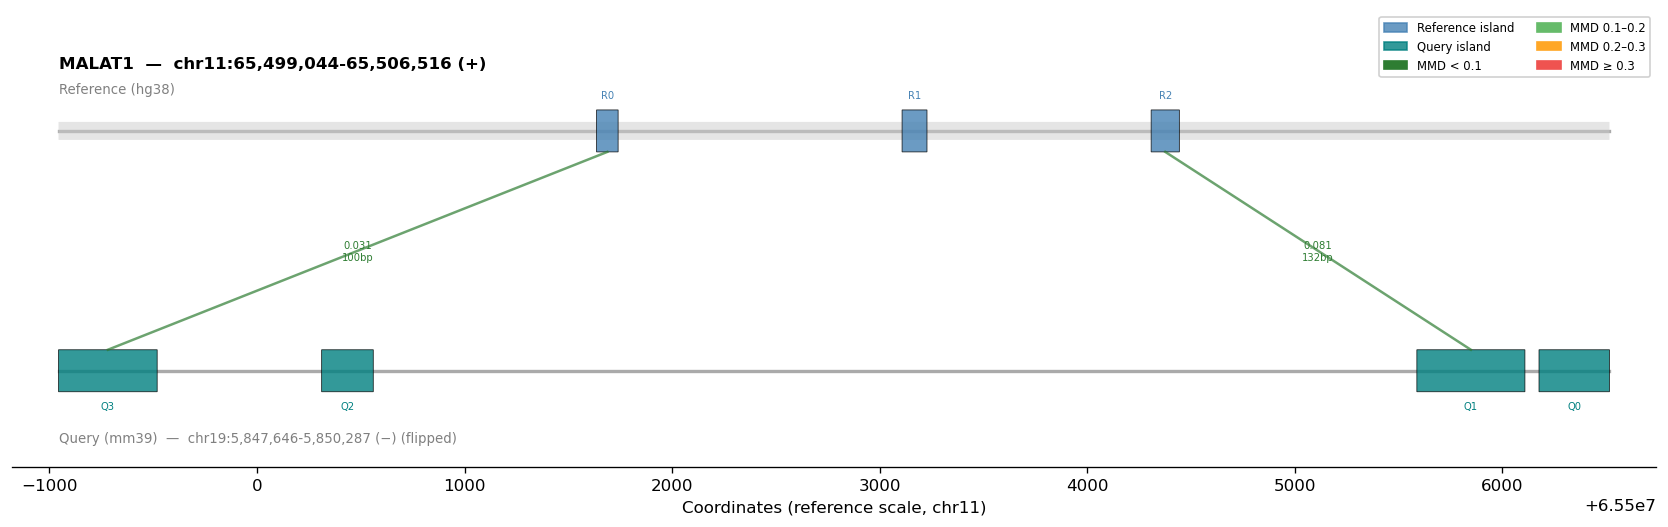


NEAT1  (U_ENSG00000245532.13)
  Biotype: lncRNA
  Reference: chr11:65,422,797-65,445,540 (+) (22,743 bp)
  Reference islands: 35
  TOGA chains: 1
  ⚠ Chain on opposite strand — query display is flipped
  Query islands: 50
  Matched island pairs: 19

  Island matches:
    R1 ↔ Q58: MMD=0.0852, match=184bp, ref=424bp, query=200bp
    R10 ↔ Q41: MMD=0.0727, match=112bp, ref=120bp, query=136bp
    R12 ↔ Q38: MMD=0.0804, match=192bp, ref=200bp, query=168bp
    R13 ↔ Q36: MMD=0.0866, match=220bp, ref=248bp, query=200bp
    R15 ↔ Q35: MMD=0.0574, match=116bp, ref=136bp, query=120bp
    R17 ↔ Q33: MMD=0.0602, match=96bp, ref=296bp, query=88bp
    R18 ↔ Q24: MMD=0.1207, match=136bp, ref=136bp, query=136bp
    R2 ↔ Q56: MMD=0.0495, match=124bp, ref=136bp, query=120bp
    R22 ↔ Q23: MMD=0.1334, match=96bp, ref=200bp, query=120bp
    R23 ↔ Q22: MMD=0.0124, match=144bp, ref=152bp, query=120bp
    R27 ↔ Q15: MMD=0.0750, match=96bp, ref=232bp, query=88bp
    R31 ↔ Q7: MMD=0.0656, match=152bp, ref=20

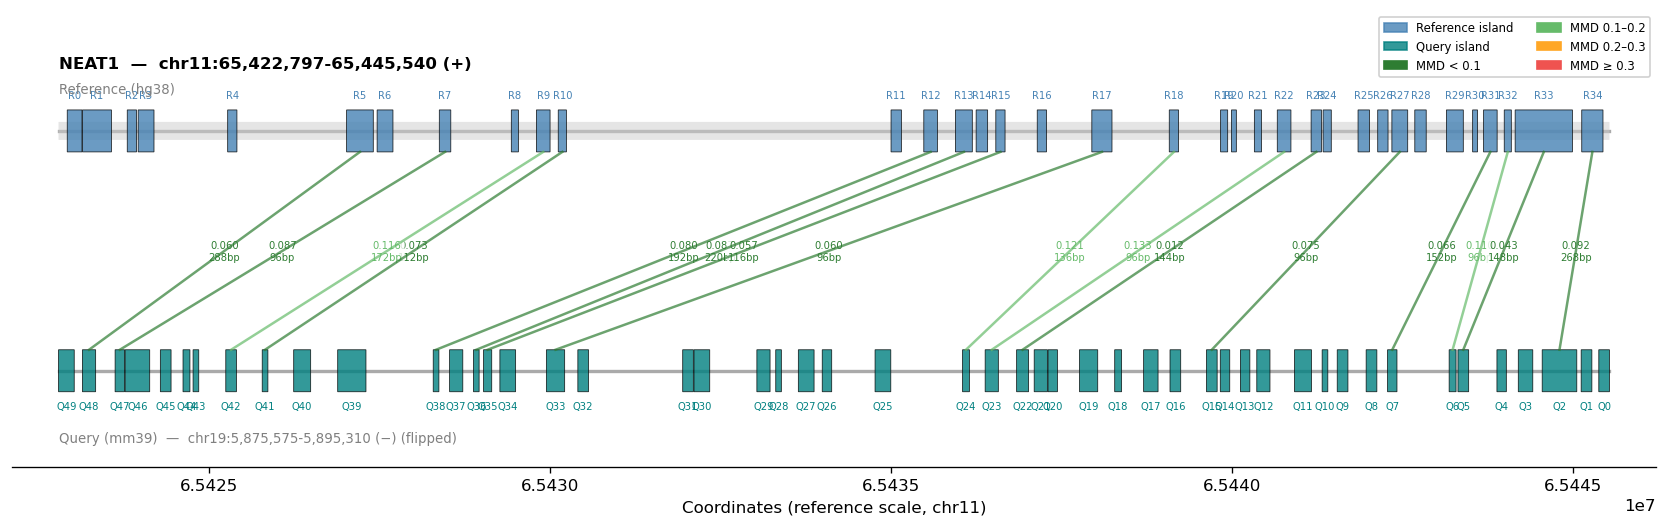


XIST  (U_ENSG00000229807.15)
  Biotype: lncRNA
  Reference: chrX:73,820,655-73,852,714 (-) (32,059 bp)
  Reference islands: 13
  TOGA chains: 1
  Query islands: 7
  Matched island pairs: 5

  Island matches:
    R0 ↔ Q0: MMD=0.0596, match=72bp, ref=72bp, query=104bp
    R3 ↔ Q2: MMD=0.1218, match=104bp, ref=104bp, query=104bp
    R5 ↔ Q4: MMD=0.0746, match=88bp, ref=88bp, query=88bp
    R5 ↔ Q5: MMD=0.0682, match=88bp, ref=88bp, query=72bp
    R9 ↔ Q6: MMD=0.0787, match=144bp, ref=184bp, query=280bp


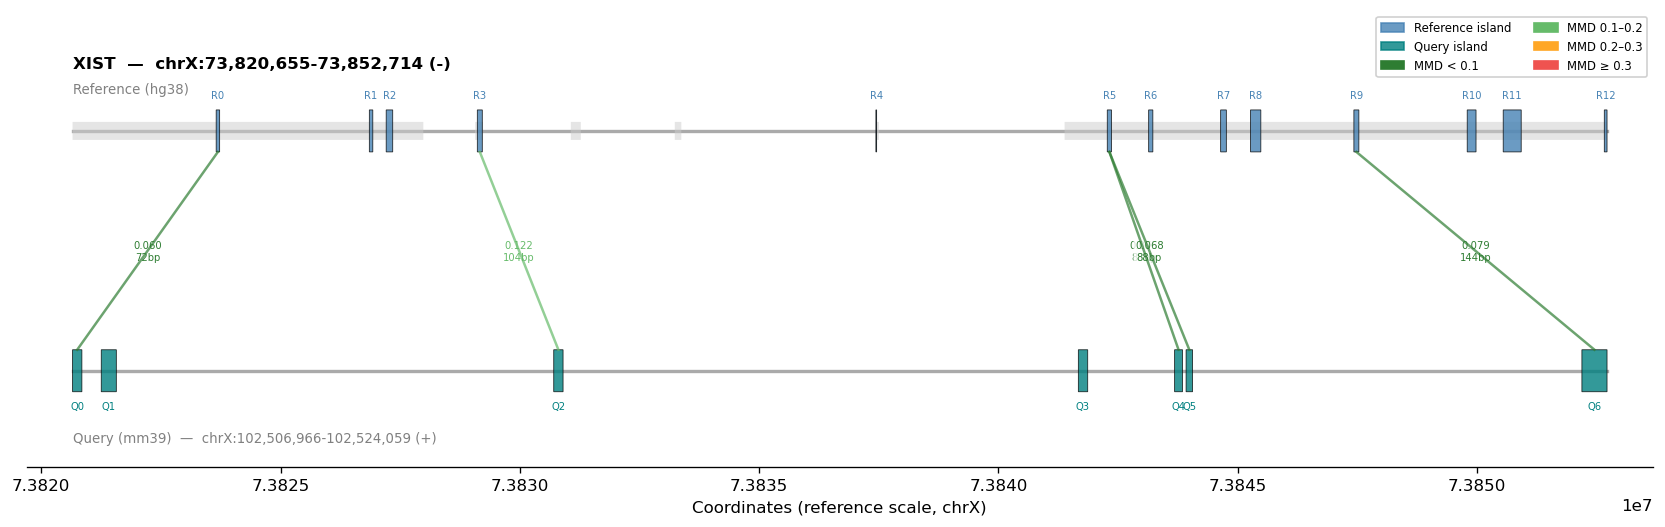


HOTAIR  (U_ENSG00000228630.8)
  Biotype: lncRNA
  Reference: chr12:53,953,597-53,985,549 (-) (31,952 bp)
  Reference islands: 0
  TOGA chains: 0
  Query islands: 0
  Matched island pairs: 0
  HOTAIR: no structural islands detected, skipping plot.

H19  (U_ENSG00000130600.23)
  Biotype: retained_intron
  Reference: chr11:1,995,175-2,001,706 (-) (6,531 bp)
  Reference islands: 0
  TOGA chains: 0
  Query islands: 0
  Matched island pairs: 0
  H19: no structural islands detected, skipping plot.

MEG3  (U_ENSG00000258399.10)
  Biotype: lncRNA
  Reference: chr14:100,826,117-100,986,938 (+) (160,821 bp)
  Reference islands: 43
  TOGA chains: 15
  Query islands: 0
  Matched island pairs: 0


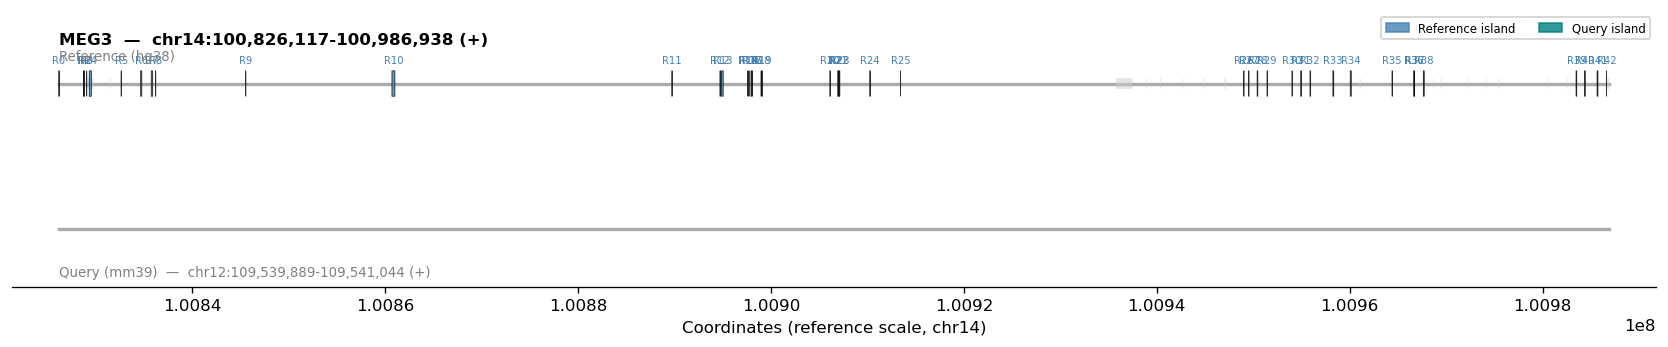


GAS5  (U_ENSG00000234741.11)
  Biotype: retained_intron
  Reference: chr1:173,863,894-173,867,996 (-) (4,102 bp)
  Reference islands: 0
  TOGA chains: 0
  Query islands: 0
  Matched island pairs: 0
  GAS5: no structural islands detected, skipping plot.

BISPR  (U_ENSG00000282851.2)
  Biotype: lncRNA
  Reference: chr19:17,406,103-17,419,324 (+) (13,221 bp)
  Reference islands: 0
  TOGA chains: 0
  Query islands: 0
  Matched island pairs: 0
  BISPR: no structural islands detected, skipping plot.

KCNQ1OT1  (U_ENSG00000269821.2)
  Biotype: lncRNA
  Reference: chr11:2,608,327-2,699,994 (-) (91,667 bp)
  Reference islands: 121
  TOGA chains: 1
  Query islands: 80
  Matched island pairs: 48

  Island matches:
    R100 ↔ Q56: MMD=0.1080, match=96bp, ref=856bp, query=72bp
    R101 ↔ Q58: MMD=0.0582, match=112bp, ref=264bp, query=136bp
    R102 ↔ Q59: MMD=0.0741, match=188bp, ref=600bp, query=264bp
    R105 ↔ Q60: MMD=0.0365, match=160bp, ref=168bp, query=136bp
    R106 ↔ Q61: MMD=0.0946, matc

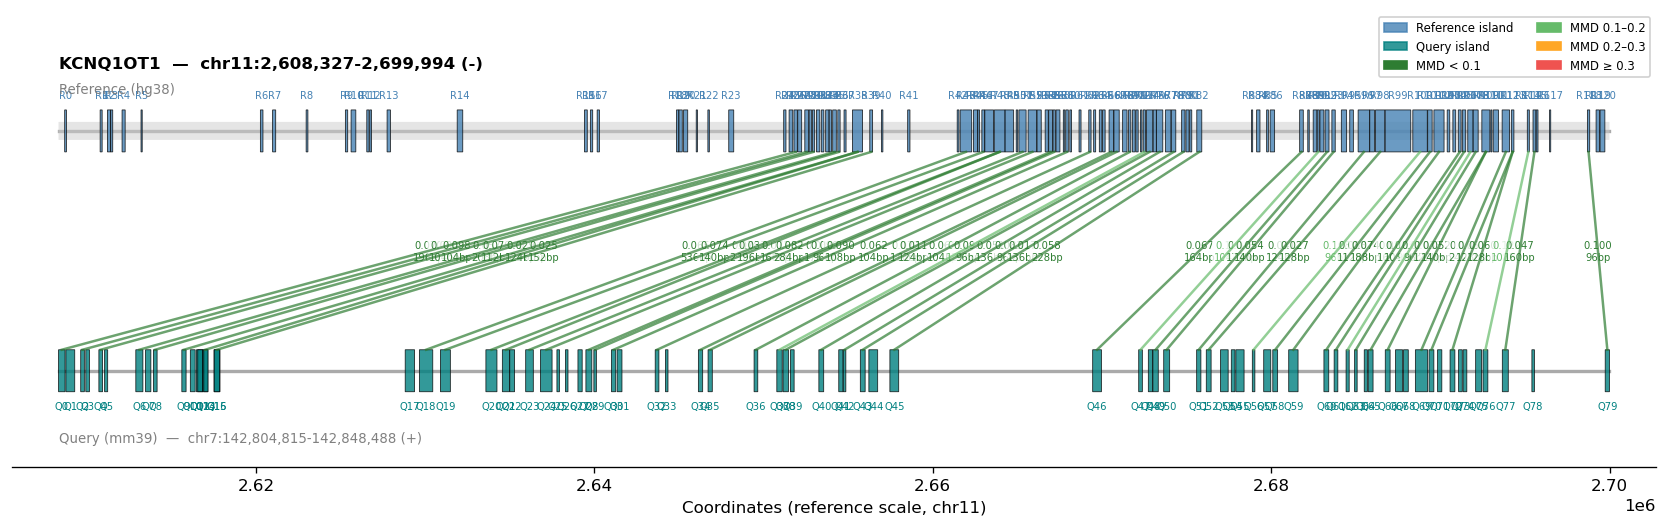

In [6]:
for name in TARGETS.values():
    data = gene_data.get(name)
    if data is None:
        print(f"\n{'='*60}")
        print(f"{name}: not found in union transcripts")
        continue

    ref_islands = data["ref_islands"]
    q_islands = data["query_islands"]
    matches_df = data["alignments"][data["alignments"]["type"] == "match"]

    print(f"\n{'='*60}")
    print(f"{name}  ({data['uid']})")
    print(f"  Biotype: {data['biotype']}")
    print(f"  Reference: {data['union']['chrom']}:{data['union']['start']:,}-{data['union']['end']:,} "
          f"({data['union']['strand']}) ({data['union']['end'] - data['union']['start']:,} bp)")
    print(f"  Reference islands: {len(ref_islands)}")
    print(f"  TOGA chains: {len(data['toga'])}")
    if data.get("flip_query", False):
        print(f"  ⚠ Chain on opposite strand — query display is flipped")
    print(f"  Query islands: {len(q_islands)}")
    print(f"  Matched island pairs: {len(matches_df)}")

    if len(matches_df) > 0:
        print(f"\n  Island matches:")
        for _, row in matches_df.iterrows():
            match_len = int(row["chain1_ref_to"] - row["chain1_ref_from"])
            print(f"    {row['ref_island']} ↔ {row['query_island']}: "
                  f"MMD={row['diag_mmd']:.4f}, match={match_len}bp, "
                  f"ref={row['ref_len']}bp, query={row['query_len']}bp")

    plot_gene(data)

## Summary table

In [7]:
summary_rows = []
for ensg, name in TARGETS.items():
    d = gene_data.get(name)
    if d is None:
        summary_rows.append({
            "Gene": name, "ENSG": ensg, "Status": "not in union",
            "Biotype": "-", "Ref len": "-", "Ref islands": 0,
            "TOGA chains": 0, "Query islands": 0, "Matches": 0,
            "Median MMD": "-",
        })
        continue

    matches_df = d["alignments"][d["alignments"]["type"] == "match"]
    med_mmd = f"{matches_df['diag_mmd'].median():.3f}" if len(matches_df) > 0 else "-"
    ref_len = d["union"]["end"] - d["union"]["start"]
    status = "OK" if len(d["ref_islands"]) > 0 else "no islands"

    summary_rows.append({
        "Gene": name,
        "ENSG": ensg,
        "Status": status,
        "Biotype": d["biotype"],
        "Ref len": f"{ref_len:,}",
        "Ref islands": len(d["ref_islands"]),
        "TOGA chains": len(d["toga"]),
        "Query islands": len(d["query_islands"]),
        "Matches": len(matches_df),
        "Median MMD": med_mmd,
    })

summary = pd.DataFrame(summary_rows)
summary

,Gene,ENSG,Status,Biotype,Ref len,Ref islands,TOGA chains,Query islands,Matches,Median MMD
0,MALAT1,ENSG00000251562,OK,lncRNA,"7,472",3,1,4,2,0.056
1,NEAT1,ENSG00000245532,OK,lncRNA,"22,743",35,1,50,19,0.080
2,XIST,ENSG00000229807,OK,lncRNA,"32,059",13,1,7,5,0.075
3,HOTAIR,ENSG00000228630,no islands,lncRNA,"31,952",0,0,0,0,-
4,H19,ENSG00000130600,no islands,retained_intron,"6,531",0,0,0,0,-
5,MEG3,ENSG00000214548,OK,lncRNA,"160,821",43,15,0,0,-
6,GAS5,ENSG00000234741,no islands,retained_intron,"4,102",0,0,0,0,-
7,BISPR,ENSG00000282851,no islands,lncRNA,"13,221",0,0,0,0,-
8,KCNQ1OT1,ENSG00000269821,OK,lncRNA,"91,667",121,1,80,48,0.062
